<h1>Homework 2<h1>

<p>When we write papers, we often summarize the descriptive statistics for the data that we use. 
We can easily do this in Python. We need to create a matrix or data frame with just the information we need. 
We also create a visuallly pleasing correlation matrix of our variables.</p>
<p>The variables are:</p>

<p>•	Coffee Price: dollars per pound<br />
•	Sugar Price: dollars per pound<br />
•	Tea Price: dollars per pound<br />
•	Family Income: annual family salary in U.S. dollars<br />
•	Coffee consumption: cups annually per person</p>


In [2]:
# -----------------------------------------------------------
# HOMEWORK 2: MULTIPLE LINEAR REGRESSION ANALYSIS
# -----------------------------------------------------------
# This program:
# 1. Loads economic data
# 2. Creates per capita variables
# 3. Computes descriptive statistics
# 4. Visualizes correlations using a heatmap
# 5. Estimates a multiple linear regression model
# 6. Estimates a log-log (elasticity) regression model
# -----------------------------------------------------------

# -----------------------------------------------------------
# STEP 1: IMPORT LIBRARIES
# -----------------------------------------------------------

import pandas as pd              # Data manipulation
import numpy as np               # Numerical operations
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns            # Advanced visualization

# Library for regression models
from statsmodels.formula.api import ols


# -----------------------------------------------------------
# STEP 2: LOAD THE DATA
# -----------------------------------------------------------

# Read the Excel file into a Pandas DataFrame
# Make sure the file is in the same folder as your script
df = pd.read_csv('Coffee_demand.csv')

# Display the first five observations
df.head()

,Year,Coffee_consumption,Coffee_price,Sugar_price,Tea_price,Annual_income
0,1990,267.22,0.91,0.13,0.92,42650
1,1991,270.57,0.86,0.09,0.84,43240
2,1992,309.06,0.65,0.09,0.91,44220
3,1993,301.31,0.69,0.10,0.84,47220
4,1994,214.79,1.45,0.12,0.83,49340


<p>We display the descriptive statistics first.</p>

In [3]:
# -----------------------------------------------------------
# STEP 3: SELECT VARIABLES FOR ANALYSIS
# -----------------------------------------------------------

# These are the key variables used in the analysis
X = df[['Coffee_consumption', 'Coffee_price', 'Sugar_price', 'Tea_price', 'Annual_income']]

# -----------------------------------------------------------
# STEP 4: DESCRIPTIVE STATISTICS (TABLE FORMAT)
# -----------------------------------------------------------
# This creates a clean summary table for all variables

# Use Pandas describe() and extend it
desc_stats = X.describe().T   # Transpose so variables are rows

# Add additional statistics
desc_stats['skewness'] = X.skew()

# Rename columns for clarity
desc_stats.rename(columns={
    'count': 'Count',
    'mean': 'Mean',
    'std': 'Std Dev',
    'min': 'Min',
    '25%': '25%',
    '50%': 'Median',
    '75%': '75%',
    'max': 'Max'
}, inplace=True)

# Round values for readability
desc_stats = desc_stats.round(3)

# Display the table
print('\n----- DESCRIPTIVE STATISTICS TABLE -----')
print(desc_stats)




----- DESCRIPTIVE STATISTICS TABLE -----
                    Count       Mean    Std Dev       Min        25%  \
Coffee_consumption   34.0    317.541     63.351    180.05    270.022   
Coffee_price         34.0      1.247      0.454      0.54      0.938   
Sugar_price          34.0      0.133      0.053      0.06      0.092   
Tea_price            34.0      1.128      0.255      0.75      0.903   
Annual_income        34.0  78548.529  25220.285  42650.00  60335.000   

                       Median        75%        Max  skewness  
Coffee_consumption    317.785    361.220     437.73    -0.196  
Coffee_price            1.220      1.458       2.53     0.665  
Sugar_price             0.120      0.168       0.27     0.806  
Tea_price               1.090      1.298       1.65     0.448  
Annual_income       77750.000  91695.000  135700.00     0.562  


<p>We display the correlation matrix next<p>

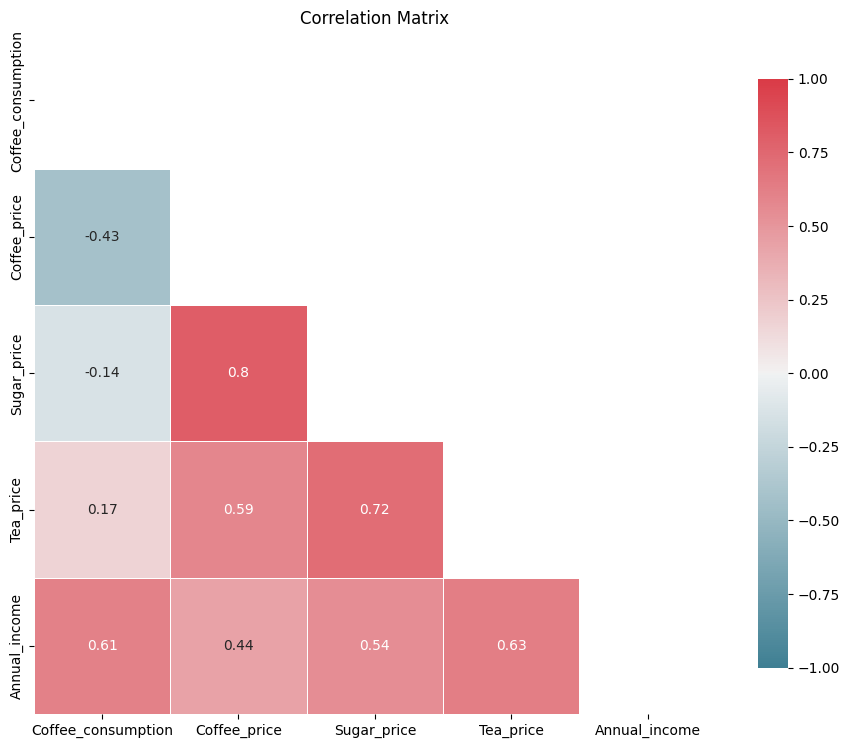

In [4]:
# -----------------------------------------------------------
# STEP 5: CORRELATION MATRIX
# -----------------------------------------------------------
# Correlation measures the strength of relationships between variables

corr = X.corr()

# Create a mask to hide the upper triangle of the matrix
# (This avoids showing duplicate information)
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the plot
fig, ax = plt.subplots(figsize=(11, 9))

# Create a color palette
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap
sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    annot=True,        # Show numbers in each cell
    vmax=1, vmin=-1,   # Correlation ranges from -1 to 1
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.85}
)

# Title for clarity
plt.title('Correlation Matrix')

# Save the figure (high resolution)
plt.savefig('Figure-Correlation.png', bbox_inches='tight', dpi=600)

# Show the plot
plt.show()

<p>We estimate the simple linear regression for coffee demand</p>

In [6]:
# -----------------------------------------------------------
# STEP 6: MULTIPLE LINEAR REGRESSION (LEVELS)
# -----------------------------------------------------------
# This model estimates how prices and income affect coffee demand

# Define and estimate the model
Model_01 = ols(
    'Coffee_consumption ~ Coffee_price + Sugar_price + Tea_price + Annual_income',
    data=df
).fit()

# Display results
print('\n----- REGRESSION RESULTS: LEVEL MODEL -----')
print(Model_01.summary())


----- REGRESSION RESULTS: LEVEL MODEL -----
                            OLS Regression Results                            
Dep. Variable:     Coffee_consumption   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     325.5
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           1.22e-23
Time:                        12:45:08   Log-Likelihood:                -123.74
No. Observations:                  34   AIC:                             257.5
Df Residuals:                      29   BIC:                             265.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
I

<p>We take the natural logarithm of all the variables. Then we estimate the non-linear demand function.
The parameter estimates become the elasticities.</p>

In [7]:
# -----------------------------------------------------------
# STEP 8: LOG TRANSFORMATION
# -----------------------------------------------------------
# Taking logs helps:
# - Interpret coefficients as elasticities
# - Reduce skewness in data
# - Improve model fit

df['ln_Coffee_consumption'] = np.log(df['Coffee_consumption'])
df['ln_Coffee_price'] = np.log(df['Coffee_price'])
df['ln_Sugar_price'] = np.log(df['Sugar_price'])
df['ln_Tea_price'] = np.log(df['Tea_price'])
df['ln_Annual_income'] = np.log(df['Annual_income'])


# -----------------------------------------------------------
# STEP 9: LOG-LOG REGRESSION MODEL
# -----------------------------------------------------------
# In this model, coefficients represent percentage changes
# (i.e., elasticities)

Model_02 = ols(
    'ln_Coffee_consumption ~ ln_Coffee_price + ln_Sugar_price + ln_Tea_price + ln_Annual_income',
    data=df
).fit()

# Display results
print('\n----- REGRESSION RESULTS: LOG-LOG MODEL -----')
print(Model_02.summary())

# -----------------------------------------------------------
# END OF PROGRAM
# -----------------------------------------------------------


----- REGRESSION RESULTS: LOG-LOG MODEL -----
                              OLS Regression Results                             
Dep. Variable:     ln_Coffee_consumption   R-squared:                       0.906
Model:                               OLS   Adj. R-squared:                  0.893
Method:                    Least Squares   F-statistic:                     70.20
Date:                   Wed, 29 Apr 2026   Prob (F-statistic):           1.72e-14
Time:                           12:48:34   Log-Likelihood:                 45.148
No. Observations:                     34   AIC:                            -80.30
Df Residuals:                         29   BIC:                            -72.66
Df Model:                              4                                         
Covariance Type:               nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------